# Lab 0.7 - Manipulating Datasets with Pandas

## Objective
- Install and learn the basics of the `pandas` library.
- Manipulate and analyze datasets, finding basic statistics and adding/removing columns.
- Create data visualizations using `matplotlib`.

## Rubric
- 6 pts - Contains all required components and uses professional language and commenting
- 5 pts - Contains all required components, but uses unprofessional language, commenting, etc. 
- 4 pts - Contains some, but not all, of the required components
- 3 pts - Did not submit

# Instructions

Fill in the following code boxes. **Answer the numbered questions in comments next to the code you used to find the answer**.

# Problem 1: Weather Data

We are going to analyze the dataset you created. Use `import pandas as pd` to import the `pandas` library. Then use `df = pd.read_csv("filename.csv")` to create a `DataFrame` called `df`. 

In [2]:
import pandas as pd 
df = pd.read_csv("weather.csv")

### `pandas` method reference

- `df.head(x)` and `df.tail(x)` will give you the first or the last `x` number of rows respectively
- `df.describe()` will give you a **five number summary** of the numeric columns
- `df.max()` and `.min()` will with you the maximum and the minimum of the column repectively
- `df[column]` will give you the column specified
- `df.iloc[index]` will give you the row at a given index
- `df.boxplot` will create a box plot of all numeric columns
- `df.sort_values(by=col, ascending=False)`sorts the values of the col in either ascending or descending order


1. What is the last entry in your table?

In [3]:
print(df.tail(1))

           datetime  temp_c  temp_f humidity
784  02/04/25 20:18    21.8    71.2    27.5%


2. What is the average temperature(either outside or inside) over your 40 hour period. What is the lowest temperature? What is the highest temperature? 

In [4]:
print(df.sort_values(by="temp_f", ascending=False).head(1))
print("\n")
print(df.sort_values(by="temp_f", ascending=True).head(1))
print("\n")
average = 0
for x in range(len(df)):
    tempeture = df["temp_f"]
    average = average + int(tempeture[x])
print(average/len(df), "degrees Farenhieght")

           datetime  temp_c  temp_f humidity
756  02/04/25 16:23    23.0    73.4    28.4%


           datetime  temp_c  temp_f humidity
589  02/03/25 21:01    19.1    66.4    27.6%


68.54394904458599 degrees Farenhieght


3. Create a boxplot of the temperatures.

<function matplotlib.pyplot.show(close=None, block=None)>

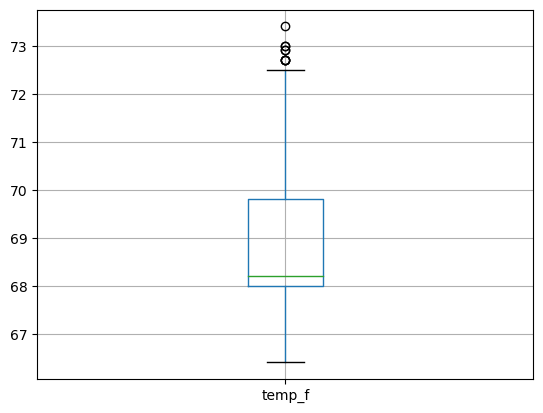

In [5]:
import matplotlib.pyplot as plt
df[["temp_f"]].boxplot()
plt.show

4. Create a plot of temperature over time with `matplotlib`. 

Import the library with `import matplotlib.pyplot as plt`. The `plot()` method creates a line graphs of temperature over time. Use `plt.plot(df['x_col'],df['y_col'],marker='h')` then `plt.show()` to create your plot of temperature over time. 

Before `plt.show()`, add the following methods to modify your graph. Remember, **good graphs always have axis labels, a title, clear units etc.**

```
plt.xlabel('') # labels the x-axis
plt.ylabel('') # labels the y-axis
plt.title('') # adds a graph title
plt.grid() # adds gridlines
plt.legend() # adds a legend
plt.xticks(rotation=90) # rotates the x-axis tick lables
plt.yticks(rotation=90) # rotates the y-axis tick lables
```

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


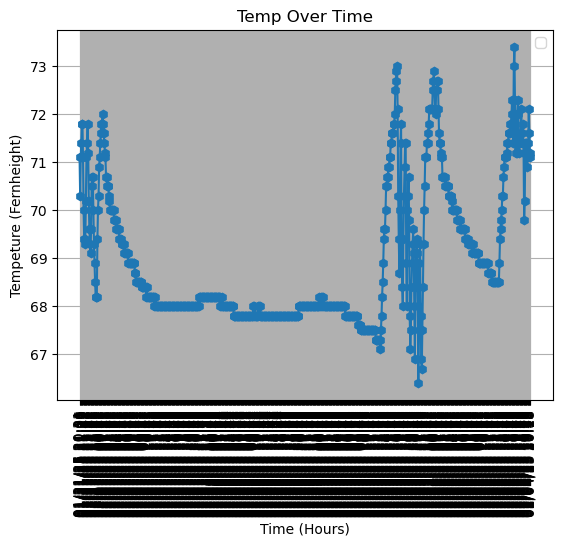

In [6]:
import matplotlib.pyplot as plt

plt.plot(df["datetime"],df['temp_f'],marker='h')
plt.xlabel('Time (Hours)')
plt.ylabel('Tempeture (Fernheight)')
plt.title("Temp Over Time")
plt.grid()
plt.legend()
plt.xticks(rotation=90)


plt.show()

5. Define a new column called `kelvin` which is your `celsius` column + 273.15. 

In [7]:
df["temp_k"] = df["temp_c"] + 273.15
print(df)

           datetime  temp_c  temp_f humidity  temp_k
0    01/31/25 20:31    21.7    71.1    22.5%  294.85
1    01/31/25 20:36    21.3    70.3    22.7%  294.45
2    01/31/25 21:01    21.7    71.1    21.9%  294.85
3    01/31/25 21:06    21.9    71.4    21.6%  295.05
4    01/31/25 21:11    22.1    71.8    21.7%  295.25
..              ...     ...     ...      ...     ...
780  02/04/25 19:38    21.9    71.4    27.5%  295.05
781  02/04/25 19:43    22.3    72.1    27.3%  295.45
782  02/04/25 19:58    22.0    71.6    27.2%  295.15
783  02/04/25 20:13    21.7    71.1    27.5%  294.85
784  02/04/25 20:18    21.8    71.2    27.5%  294.95

[785 rows x 5 columns]


6. Get the record(row) at 2:30PM 


In [8]:
for x in range(len(df)):
    time = df["datetime"]
    y,z = time[x].split(" ")
    start, end = z.split(":")
    if start == "14" and int(end) >= 30 and int(end) <= 39:
        print(df.iloc[x])
        print("\n")

datetime    02/01/25 14:38
temp_c                20.0
temp_f                68.0
humidity             23.7%
temp_k              293.15
Name: 155, dtype: object


datetime    02/02/25 14:34
temp_c                19.9
temp_f                67.8
humidity             27.2%
temp_k              293.05
Name: 341, dtype: object


datetime    02/02/25 14:39
temp_c                19.9
temp_f                67.8
humidity             27.2%
temp_k              293.05
Name: 342, dtype: object


datetime    02/03/25 14:31
temp_c                21.4
temp_f                70.5
humidity             24.7%
temp_k              294.55
Name: 534, dtype: object


datetime    02/03/25 14:36
temp_c                21.5
temp_f                70.7
humidity             24.8%
temp_k              294.65
Name: 535, dtype: object


datetime    02/04/25 14:33
temp_c                21.7
temp_f                71.1
humidity             26.6%
temp_k              294.85
Name: 740, dtype: object


datetime    02/04/25 14:38
t

# Problem 2: Population Data

In this example we will fetch data about countries and their predicted populations from [Wikipedia](http://en.wikipedia.org/wiki/List_of_countries_by_past_and_future_population).

I have done the web scraping and creation of a `DataFrame`,`df_a`.

In [9]:
import numpy as np
import pandas as pd
import requests
from bs4 import BeautifulSoup


url = 'http://en.wikipedia.org/wiki/List_of_countries_by_past_and_future_population'
page = requests.get(url)
soup = BeautifulSoup(page.content, "html.parser")

tbody = soup.find_all("tbody")
tr = tbody[0].find_all("tr")
arr = []
mat = []
for t in tr:
    lst = t.text.split("\n")
    for l in lst:
        if l == "":
            if arr != []:
                arr = arr[0:2] + arr[2::2]
                mat.append(arr)
                arr = []
        else:
            try: 
                arr.append(int(l.lstrip('\xa0').replace(",","")))
            except ValueError:
                arr.append(str(l.lstrip('\xa0').replace(",","")))
titles = mat[0]
titles[0] = "countries"
mat = mat[1:]
df_a = pd.DataFrame.from_records(mat, columns=titles) 


1. A 5 number summary of `df_a`

In [10]:
df_a.describe()

,2024,2030,2100
count,2.580000e+02,2.580000e+02,2.580000e+02
mean,1.409838e+08,1.483421e+08,2.564182e+08
std,6.587727e+08,6.906787e+08,1.679245e+09
min,5.260000e+02,5.610000e+02,1.237000e+03
25%,5.999040e+05,6.259820e+05,6.768595e+05
50%,6.893438e+06,7.254900e+06,8.156020e+06
75%,3.483818e+07,3.830878e+07,5.201191e+07
max,8.118836e+09,8.546141e+09,2.290128e+10


2. How is the `DataFrame` currently indexed? If it is not already, make the `countries` column the index.

In [11]:
df_a.set_index("countries", inplace=False)

,2024,2030,2100
countries,,,
World,8118836000,8546141000,22901278109
Asia,4785060000,4958807000,12902801109
Africa,1494994000,1710666000,3924421000
Sub-Saharan Africa,1226534000,1417346000,3442347000
Central Asia and South Asia,2128585000,2258687000,2559659000
...,...,...,...
Venezuela,29395334,32027461,35353213
Vietnam,99497680,102699905,91036732
Yemen,35219853,39923245,74176034


3. What is the largest population listed for 2030?

In [12]:
df_a.sort_values(by=2030, ascending=False)
df_a[2030].iloc[0]

8546141000

4. What was the population of Austria from now to 2100?

In [13]:
for x in range(len(df_a)):
    if df_a['countries'].iloc[x] == "Austria":
        print(df_a.iloc[x])

countries    Austria
2024         9120813
2030         9080346
2100         7399328
Name: 33, dtype: object


5. What will the population be of France in 2030?

In [14]:
for x in range(len(df_a)):
    if df_a['countries'].iloc[x] == "France":
        print(df_a[2030].iloc[x])

65543452


6. What 5 entries will have the highest population in 2100? Display their records.

In [15]:
df_a.sort_values(by=2100, ascending=False)
for x in range(5):
    print(df_a['countries'].iloc[x])

World
Asia
Africa
Sub-Saharan Africa
Central Asia and South Asia


7. What was country with the smallest population in 2024?

In [16]:
df_a.sort_values(by=2024,ascending = False).tail(1)['countries']


188    Vatican City
Name: countries, dtype: object

8. Create a plot with `plot()` to compare the population of Austria, Germany, United States, and France from 2024-2100. Your graph needs to include a  proper title, axis labels, and legend.

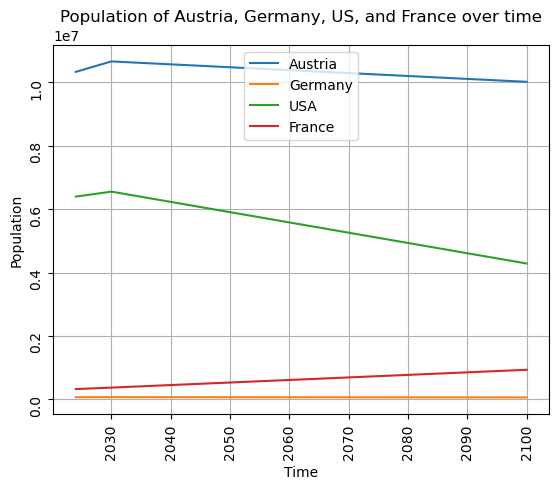

In [18]:
import matplotlib.pyplot as plt

years = [2024, 2030, 2100]

austria = [int(df_a[2024].iloc[34]), int(df_a[2030].iloc[34]), int(df_a[2100].iloc[34])]
germany = [int(df_a[2024].iloc[68]), int(df_a[2030].iloc[68]), int(df_a[2100].iloc[68])]
united_states = [int(df_a[2024].iloc[178]), int(df_a[2030].iloc[178]), int(df_a[2100].iloc[178])]
france = [int(df_a[2024].iloc[231]), int(df_a[2030].iloc[231]), int(df_a[2100].iloc[231])]

plt.plot(years, austria, label = 'Austria')
plt.plot(years, germany, label = 'Germany')
plt.plot(years, united_states, label = "USA")
plt.plot(years, france, label = 'France')
plt.xlabel('Time')    
plt.ylabel('Population')
plt.title('Population of Austria, Germany, US, and France over time')
plt.grid()
plt.legend()
plt.xticks(rotation=90)
plt.yticks(rotation=90)

plt.show()